<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/Lab_ID3_ThucHanh_ChiTiet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BƯỚC 0 — Cài đặt thư viện cần thiết

In [12]:
import pandas as pd
import numpy as np
import math
from collections import Counter

pd.set_option('display.max_columns', None)
print("Đã import xong các thư viện cần thiết ✅")

Đã import xong các thư viện cần thiết ✅


BƯỚC 1 — Khởi tạo dữ liệu huấn luyện

In [13]:
data = {
    "ID":          ["D1","D2","D3","D4","D5","D6","D7","D8","D9","D10","D11","D12","D13","D14"],
    "Outlook":     ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                    "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
                    "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity":    ["High","High","High","High","Normal","Normal","Normal",
                    "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind":        ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
                    "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "Play":        ["No","No","Yes","Yes","Yes","No","Yes",
                    "No","Yes","Yes","Yes","Yes","Yes","No"],
}

df = pd.DataFrame(data).set_index("ID")

TARGET = "Play"
ATTRIBUTES = ["Outlook", "Temperature", "Humidity", "Wind"]

print(f"Tổng số mẫu: {len(df)}")
df

Tổng số mẫu: 14


,Outlook,Temperature,Humidity,Wind,Play
ID,,,,,
D1,Sunny,Hot,High,Weak,No
D2,Sunny,Hot,High,Strong,No
D3,Overcast,Hot,High,Weak,Yes
D4,Rain,Mild,High,Weak,Yes
D5,Rain,Cool,Normal,Weak,Yes
D6,Rain,Cool,Normal,Strong,No
D7,Overcast,Cool,Normal,Strong,Yes
D8,Sunny,Mild,High,Weak,No
D9,Sunny,Cool,Normal,Weak,Yes


BƯỚC 2 — Chuẩn hóa & kiểm tra dữ liệu

In [14]:
# Kiểm tra dữ liệu thiếu
print("Số giá trị thiếu theo từng cột:")
print(df.isnull().sum())

print("\nKiểu dữ liệu từng cột:")
print(df.dtypes)

print("\nPhân bố lớp mục tiêu:")
print(df[TARGET].value_counts())

print("\nCác giá trị có thể của từng thuộc tính:")
for attr in ATTRIBUTES:
    print(f"  - {attr}: {sorted(df[attr].unique())}")

Số giá trị thiếu theo từng cột:
Outlook        0
Temperature    0
Humidity       0
Wind           0
Play           0
dtype: int64

Kiểu dữ liệu từng cột:
Outlook        object
Temperature    object
Humidity       object
Wind           object
Play           object
dtype: object

Phân bố lớp mục tiêu:
Play
Yes    9
No     5
Name: count, dtype: int64

Các giá trị có thể của từng thuộc tính:
  - Outlook: ['Overcast', 'Rain', 'Sunny']
  - Temperature: ['Cool', 'Hot', 'Mild']
  - Humidity: ['High', 'Normal']
  - Wind: ['Strong', 'Weak']


BƯỚC 3 — Cài đặt hàm tính Entropy

In [15]:
def entropy(labels):
    '''Tính Entropy của một chuỗi (Series/list) nhãn lớp.'''
    labels = pd.Series(labels)
    total = len(labels)
    if total == 0:
        return 0.0
    counts = labels.value_counts()
    ent = 0.0
    for count in counts:
        p = count / total
        ent -= p * math.log2(p)
    return ent

# Kiểm thử: Entropy(S) toàn bộ tập dữ liệu phải xấp xỉ 0.940 (theo lý thuyết)
entropy_S = entropy(df[TARGET])
print(f"Entropy(S) = {entropy_S:.3f}   (kỳ vọng theo lý thuyết ≈ 0.940)")

Entropy(S) = 0.940   (kỳ vọng theo lý thuyết ≈ 0.940)


BƯỚC 4 — Cài đặt hàm tính Information Gain

In [16]:
def information_gain(data, attribute, target):
    '''Tính Information Gain khi phân chia `data` theo `attribute`.'''
    total_entropy = entropy(data[target])
    total_len = len(data)

    weighted_entropy = 0.0
    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        weight = len(subset) / total_len
        weighted_entropy += weight * entropy(subset[target])

    return total_entropy - weighted_entropy

# Kiểm thử: tính Gain cho từng thuộc tính ở nút gốc
print("=== Gain(S, A) tại nút gốc ===")
gain_results = {}
for attr in ATTRIBUTES:
    g = information_gain(df, attr, TARGET)
    gain_results[attr] = g
    print(f"  Gain(S, {attr:12s}) = {g:.3f}")

best_root = max(gain_results, key=gain_results.get)
print(f"\n=> Thuộc tính được chọn làm NÚT GỐC: {best_root}  (Gain = {gain_results[best_root]:.3f})")
print("   (Kỳ vọng theo lý thuyết: Outlook, Gain ≈ 0.246)")

=== Gain(S, A) tại nút gốc ===
  Gain(S, Outlook     ) = 0.247
  Gain(S, Temperature ) = 0.029
  Gain(S, Humidity    ) = 0.152
  Gain(S, Wind        ) = 0.048

=> Thuộc tính được chọn làm NÚT GỐC: Outlook  (Gain = 0.247)
   (Kỳ vọng theo lý thuyết: Outlook, Gain ≈ 0.246)


BƯỚC 5 — Cài đặt thuật toán ID3 (đệ quy)

In [17]:
def build_id3(data, attributes, target):
    labels = data[target].unique()

    # Điều kiện dừng 1: tất cả mẫu cùng 1 lớp
    if len(labels) == 1:
        return {"leaf": True, "label": labels[0]}

    # Điều kiện dừng 2: hết thuộc tính để chia
    if len(attributes) == 0:
        majority_label = data[target].value_counts().idxmax()
        return {"leaf": True, "label": majority_label}

    # Chọn thuộc tính tốt nhất theo Information Gain
    gains = {a: information_gain(data, a, target) for a in attributes}
    best_attr = max(gains, key=gains.get)

    node = {
        "leaf": False,
        "attribute": best_attr,
        "gain": gains[best_attr],
        "branches": {},
        "majority": data[target].value_counts().idxmax(),
    }

    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in data[best_attr].unique():
        subset = data[data[best_attr] == value]
        if len(subset) == 0:
            node["branches"][value] = {"leaf": True, "label": node["majority"]}
        else:
            node["branches"][value] = build_id3(subset, remaining_attrs, target)

    return node

# Xây dựng cây hoàn chỉnh
tree = build_id3(df, ATTRIBUTES, TARGET)
print("Đã xây dựng xong cây quyết định ID3 ✅")

Đã xây dựng xong cây quyết định ID3 ✅


BƯỚC 6 — Trực quan hóa cây quyết định (dạng văn bản)

In [18]:
def print_tree(node, indent="", branch_label=None):
    prefix = f"{indent}[{branch_label}] -> " if branch_label is not None else indent
    if node["leaf"]:
        print(f"{prefix}LÁ: {node['label']}")
    else:
        print(f"{prefix}<{node['attribute']}>  (Gain={node['gain']:.3f})")
        for value, child in node["branches"].items():
            print_tree(child, indent + "    ", branch_label=value)

print("=== CẤU TRÚC CÂY QUYẾT ĐỊNH ID3 ===\n")
print_tree(tree)

=== CẤU TRÚC CÂY QUYẾT ĐỊNH ID3 ===

<Outlook>  (Gain=0.247)
    [Sunny] -> <Humidity>  (Gain=0.971)
        [High] -> LÁ: No
        [Normal] -> LÁ: Yes
    [Overcast] -> LÁ: Yes
    [Rain] -> <Wind>  (Gain=0.971)
        [Weak] -> LÁ: Yes
        [Strong] -> LÁ: No


BƯỚC 6b — (Tùy chọn) Vẽ cây bằng Graphviz

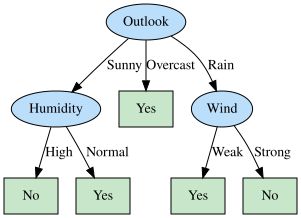

In [19]:
import graphviz

def add_nodes_edges(graph, node, node_id="root", branch_label=None, parent_id=None):
    if node["leaf"]:
        graph.node(node_id, node["label"], shape="box", style="filled", fillcolor="#c8e6c9")
    else:
        graph.node(node_id, node["attribute"], shape="ellipse", style="filled", fillcolor="#bbdefb")

    if parent_id is not None:
        graph.edge(parent_id, node_id, label=str(branch_label))

    if not node["leaf"]:
        for i, (value, child) in enumerate(node["branches"].items()):
            child_id = f"{node_id}_{i}"
            add_nodes_edges(graph, child, child_id, branch_label=value, parent_id=node_id)

dot = graphviz.Digraph()
add_nodes_edges(dot, tree)
dot

BƯỚC 7 — Sinh luật phân loại (Decision Rules) từ cây

In [20]:
def extract_rules(node, path=None, rules=None):
    if path is None:
        path = []
    if rules is None:
        rules = []

    if node["leaf"]:
        condition = " AND ".join([f"{attr} = {val}" for attr, val in path])
        rules.append(f"IF {condition} THEN {TARGET} = {node['label']}")
        return rules

    for value, child in node["branches"].items():
        extract_rules(child, path + [(node["attribute"], value)], rules)

    return rules

rules = extract_rules(tree)
print(f"=== {len(rules)} LUẬT PHÂN LOẠI RÚT RA TỪ CÂY ===\n")
for i, r in enumerate(rules, start=1):
    print(f"R{i}: {r}")

=== 5 LUẬT PHÂN LOẠI RÚT RA TỪ CÂY ===

R1: IF Outlook = Sunny AND Humidity = High THEN Play = No
R2: IF Outlook = Sunny AND Humidity = Normal THEN Play = Yes
R3: IF Outlook = Overcast THEN Play = Yes
R4: IF Outlook = Rain AND Wind = Weak THEN Play = Yes
R5: IF Outlook = Rain AND Wind = Strong THEN Play = No


BƯỚC 8 — Hàm dự đoán (Predict) & kiểm tra độ chính xác trên tập huấn luyện

In [21]:
def predict(node, sample: dict):
    if node["leaf"]:
        return node["label"]

    attr = node["attribute"]
    value = sample.get(attr)

    if value in node["branches"]:
        return predict(node["branches"][value], sample)
    else:
        # Giá trị lạ / thiếu -> trả về lớp đa số tại nút hiện tại
        return node["majority"]

# Kiểm tra lại độ chính xác trên chính tập huấn luyện (phải đạt 14/14 = 100%)
correct = 0
print(f"{'ID':4s}{'Thực tế':10s}{'Dự đoán':10s}{'Đúng?':6s}")
for idx, row in df.iterrows():
    sample = row.to_dict()
    pred = predict(tree, sample)
    is_correct = (pred == row[TARGET])
    correct += is_correct
    print(f"{idx:4s}{row[TARGET]:10s}{pred:10s}{'✓' if is_correct else '✗':6s}")

print(f"\nĐộ chính xác trên tập huấn luyện: {correct}/{len(df)} = {correct/len(df)*100:.1f}%")

ID  Thực tế   Dự đoán   Đúng? 
D1  No        No        ✓     
D2  No        No        ✓     
D3  Yes       Yes       ✓     
D4  Yes       Yes       ✓     
D5  Yes       Yes       ✓     
D6  No        No        ✓     
D7  Yes       Yes       ✓     
D8  No        No        ✓     
D9  Yes       Yes       ✓     
D10 Yes       Yes       ✓     
D11 Yes       Yes       ✓     
D12 Yes       Yes       ✓     
D13 Yes       Yes       ✓     
D14 No        No        ✓     

Độ chính xác trên tập huấn luyện: 14/14 = 100.0%


BƯỚC 9 — Nhập một trường hợp bất kỳ để kiểm tra kết *quả*


In [22]:
def input_with_options(attr_name, options):
    options_str = " / ".join(options)
    while True:
        value = input(f"Nhập {attr_name} ({options_str}): ").strip()
        # Cho phép người dùng gõ không phân biệt hoa/thường
        matched = [o for o in options if o.lower() == value.lower()]
        if matched:
            return matched[0]
        print(f"  -> Giá trị không hợp lệ, vui lòng chọn trong: {options_str}")


def predict_with_path(node, sample: dict, path=None):
    if path is None:
        path = []
    if node["leaf"]:
        return node["label"], path

    attr = node["attribute"]
    value = sample.get(attr)
    path = path + [(attr, value)]

    if value in node["branches"]:
        return predict_with_path(node["branches"][value], sample, path)
    else:
        return node["majority"], path + ["(giá trị lạ -> dùng lớp đa số)"]


print("===== NHẬP TRƯỜNG HỢP MỚI ĐỂ DỰ ĐOÁN =====")
new_sample = {}
for attr in ATTRIBUTES:
    options = sorted(df[attr].unique())
    new_sample[attr] = input_with_options(attr, options)

label, path = predict_with_path(tree, new_sample)

print("\n--- KẾT QUẢ ---")
print("Mẫu vừa nhập:", new_sample)
print("Đường đi trên cây:", " -> ".join([f"{a}={v}" for a, v in path if isinstance((a, v), tuple)]) if False else path)
print(f"\n=> DỰ ĐOÁN: {TARGET} = {label}")

===== NHẬP TRƯỜNG HỢP MỚI ĐỂ DỰ ĐOÁN =====
Nhập Outlook (Overcast / Rain / Sunny): Sunny 
Nhập Temperature (Cool / Hot / Mild): Mild 
Nhập Humidity (High / Normal): Weak 
  -> Giá trị không hợp lệ, vui lòng chọn trong: High / Normal
Nhập Humidity (High / Normal): Normal
Nhập Wind (Strong / Weak): Strong

--- KẾT QUẢ ---
Mẫu vừa nhập: {'Outlook': 'Sunny', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Strong'}
Đường đi trên cây: [('Outlook', 'Sunny'), ('Humidity', 'Normal')]

=> DỰ ĐOÁN: Play = Yes


BƯỚC 10 — (Mở rộng) Đối chiếu với sklearn.tree.DecisionTreeClassifier

In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text

df_encoded = df.copy()
encoders = {}
for col in ATTRIBUTES + [TARGET]:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df_encoded[ATTRIBUTES]
y = df_encoded[TARGET]

clf = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf.fit(X, y)

print(export_text(clf, feature_names=ATTRIBUTES))
print("Độ chính xác trên tập huấn luyện (sklearn):", clf.score(X, y))

|--- Age <= 1.50
|   |--- Credit_rating <= 0.50
|   |   |--- Income <= 1.50
|   |   |   |--- Age <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Income >  1.50
|   |   |   |--- class: 1
|   |--- Credit_rating >  0.50
|   |   |--- class: 1
|--- Age >  1.50
|   |--- Student <= 0.50
|   |   |--- class: 0
|   |--- Student >  0.50
|   |   |--- class: 1

Độ chính xác trên tập huấn luyện (sklearn): 1.0


BÀI TẬP MỞ RỘNG (TỰ LÀM THÊM)

Thay bộ dữ liệu "Đi chơi Tennis" bằng một bộ dữ liệu categorical khác (ví dụ: dự đoán mua máy tính, dự đoán duyệt vay...) và chạy lại toàn bộ pipeline

Khởi tạo dữ liệu

In [24]:
data = {
    "ID": ["C1","C2","C3","C4","C5","C6","C7","C8","C9","C10"],
    "Age": ["Youth","Youth","Middle","Senior","Senior","Senior","Middle","Youth","Youth","Senior"],
    "Income": ["High","High","High","Medium","Low","Low","Low","Medium","Low","Medium"],
    "Student": ["No","No","No","No","Yes","Yes","Yes","No","Yes","Yes"],
    "Credit_rating": ["Fair","Excellent","Fair","Fair","Fair","Excellent","Excellent","Fair","Fair","Excellent"],
    "BuyComputer": ["No","No","Yes","Yes","Yes","No","Yes","No","Yes","Yes"],
}
df = pd.DataFrame(data).set_index("ID")

TARGET = "BuyComputer"
ATTRIBUTES = ["Age","Income","Student","Credit_rating"]


Thử rời rạc hóa (discretize) một thuộc tính số liên tục (ví dụ nhiệt độ theo °C) thành các khoảng (Cold/Mild/Hot) rồi áp dụng lại ID3

Bước 1: Tạo dữ liệu có Temperature dạng số

In [26]:
data = {
    "ID": ["D1","D2","D3","D4","D5","D6","D7","D8"],
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast","Sunny"],
    "Temperature": [30, 28, 22, 18, 12, 14, 20, 32],  # số °C
    "Humidity": ["High","High","High","High","Normal","Normal","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong","Weak"],
    "Play": ["No","No","Yes","Yes","Yes","No","Yes","No"],
}
df = pd.DataFrame(data).set_index("ID")


Bước 2: Rời rạc hóa Temperature

In [27]:
def discretize_temp(temp):
    if temp < 15:
        return "Cold"
    elif temp <= 25:
        return "Mild"
    else:
        return "Hot"

df["Temp_cat"] = df["Temperature"].apply(discretize_temp)

TARGET = "Play"
ATTRIBUTES = ["Outlook","Temp_cat","Humidity","Wind"]


Bước 3: Chạy lại toàn bộ pipeline ID3


In [28]:
tree = build_id3(df, ATTRIBUTES, TARGET)
print_tree(tree)
rules = extract_rules(tree)
for r in rules:
    print(r)


<Temp_cat>  (Gain=0.750)
    [Hot] -> LÁ: No
    [Mild] -> LÁ: Yes
    [Cold] -> <Wind>  (Gain=1.000)
        [Weak] -> LÁ: Yes
        [Strong] -> LÁ: No
IF Temp_cat = Hot THEN Play = No
IF Temp_cat = Mild THEN Play = Yes
IF Temp_cat = Cold AND Wind = Weak THEN Play = Yes
IF Temp_cat = Cold AND Wind = Strong THEN Play = No


So sánh cây ID3 tự cài đặt với cây dùng Gini Index (DecisionTreeClassifier(criterion="gini")) — nhận xét sự khác biệt

Viết thêm hàm tính độ sâu (depth) và số nút lá của cây

Hàm tính độ sâu của cây

In [29]:
def tree_depth(node):
    if node["leaf"]:
        return 1
    else:
        # độ sâu = 1 + max độ sâu của các cây con
        return 1 + max(tree_depth(child) for child in node["branches"].values())

print("Độ sâu của cây:", tree_depth(tree))


Độ sâu của cây: 3


Hàm đếm số nút lá

In [30]:
def count_leaves(node):
    if node["leaf"]:
        return 1
    else:
        return sum(count_leaves(child) for child in node["branches"].values())

print("Số nút lá của cây:", count_leaves(tree))


Số nút lá của cây: 4
